In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression

# 1.  Read csv's and EDA

In [2]:
gender_submission = pd.read_csv('gender_submission.csv')
#gender_submission.info()
#gender_submission

In [3]:
test = pd.read_csv('test.csv')
test.info()
print(test.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    str    
 3   Sex          418 non-null    str    
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    str    
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     str    
 10  Embarked     418 non-null    str    
dtypes: float64(2), int64(4), str(5)
memory usage: 36.1 KB
PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64


In [4]:
test.describe()

,PassengerId,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,3.000000,76.000000,8.000000,9.000000,512.329200


In [5]:
train = pd.read_csv('train.csv')
train.info()
print(train.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [6]:
train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


# Cleaning the Data

In [7]:
# We fill the NA with the median.
test['Age'] = test['Age'].fillna(test['Age'].median())
train['Age'] = train['Age'].fillna(train['Age'].median())

In [8]:
test['Fare'] = test['Fare'].fillna(test['Fare'].median())

In [9]:
test = test.drop(columns=['Cabin'])
train = train.drop(columns=['Cabin'])

In [10]:
train['Embarked'] = train['Embarked'].fillna(train['Embarked'].mode()[0])

In [11]:
train.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [12]:
test.isnull().sum()

PassengerId    0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [ ]:
#pip install seaborn

Note: you may need to restart the kernel to use updated packages.


#### How many survived vs. how many died?

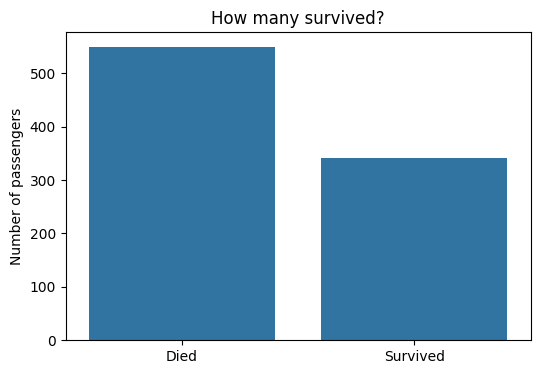

In [49]:
plt.figure(figsize=(6,4))

sns.countplot(data=train, x='Survived')

plt.title('How many survived?')
plt.xticks([0, 1], ['Died', 'Survived'])
plt.xlabel('')
plt.ylabel('Number of passengers')
plt.show()

# Feature Engineering

In [13]:
test['Family_size'] = test['SibSp'] + test['Parch'] + 1
test['Is_alone'] = (test['Family_size'] == 1).astype(int)
test

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Family_size,Is_alone
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,Q,1,1
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,S,2,0
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,Q,1,1
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,S,1,1
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,S,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,27.0,0,0,A.5. 3236,8.0500,S,1,1
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C,1,1
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,S,1,1
416,1308,3,"Ware, Mr. Frederick",male,27.0,0,0,359309,8.0500,S,1,1


In [14]:
train['Family_size'] = train['SibSp'] + train['Parch'] + 1
train['Is_alone'] = (train['Family_size'] == 1).astype(int)
train

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Family_size,Is_alone
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,2,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,2,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,1,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,2,0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S,1,1
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S,1,1
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,28.0,1,2,W./C. 6607,23.4500,S,4,0
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C,1,1


In [15]:
train['Title'] = train['Name'].str.extract(r' ([A-Za-z]+)\.')

# We group together the less common titles
train['Title'] = train['Title'].replace(['Mlle', 'Ms'], 'Miss')
train['Title'] = train['Title'].replace('Mme', 'Mrs')
train['Title'] = train['Title'].replace(['Dr','Rev','Major','Col','Don','Lady','Sir','Capt','Countess','Jonkheer'], 'Rare')


print(train['Title'].value_counts())                                       

Title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: count, dtype: int64


In [16]:
test['Title'] = test['Name'].str.extract(r' ([A-Za-z]+)\.')

# We group together the less common titles
test['Title'] = test['Title'].replace('Ms', 'Miss')
test['Title'] = test['Title'].replace(['Col', 'Rev', 'Dr', 'Dona'], 'Rare')


print(test['Title'].value_counts())    

Title
Mr        240
Miss       79
Mrs        72
Master     21
Rare        6
Name: count, dtype: int64


### Mapping

In [17]:
train['Sex'] = train['Sex'].map({'male': 0,'female': 1 })
test['Sex'] = test['Sex'].map({'male': 0, 'female': 1})

In [18]:
train['Embarked'] = train['Embarked'].map({"S": 0, "C": 1, "Q": 2})
test['Embarked'] = test['Embarked'].map({"S": 0, "C": 1, "Q": 2})

In [19]:
train['Title'] = train['Title'].map({"Mr": 0, "Miss": 1, "Mrs": 2, "Master": 3, "Rare": 4})
test['Title'] = test['Title'].map({"Mr": 0, "Miss": 1, "Mrs": 2, "Master": 3, "Rare": 4})

In [20]:
train.drop(columns=['Name', 'Ticket'], inplace=True)
test.drop(columns=['Name', 'Ticket'], inplace=True)

In [21]:
print(train.dtypes)
print(test.dtypes)

PassengerId      int64
Survived         int64
Pclass           int64
Sex              int64
Age            float64
SibSp            int64
Parch            int64
Fare           float64
Embarked         int64
Family_size      int64
Is_alone         int64
Title            int64
dtype: object
PassengerId      int64
Pclass           int64
Sex              int64
Age            float64
SibSp            int64
Parch            int64
Fare           float64
Embarked         int64
Family_size      int64
Is_alone         int64
Title            int64
dtype: object


## Training the model

In [22]:
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'Family_size', 'Is_alone', 'Title']
x = train[features]
y = train['Survived']

x_test = test[features]

In [23]:
model = RandomForestClassifier(n_estimators= 100, max_depth= 7, random_state= 42)
model.fit(x,y)
print('Modelo entrenado')

Modelo entrenado


In [24]:
#Cross Validation
scores = cross_val_score(model, x, y, cv=5, scoring='accuracy')

print(f'scores for fold {scores.round(3)}')
print(f'Mean {scores.mean().round(3)}')
print(f'Standard deviation {scores.std().round(3)}')

scores for fold [0.844 0.815 0.837 0.803 0.843]
Mean 0.828
Standard deviation 0.016


# Generate predictions

In [25]:
predictions = model.predict(x_test)

In [26]:
df_predictions = pd.DataFrame({'PassengerId': test['PassengerId'], 'Survived': predictions})
df_predictions

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1
...,...,...
413,1305,0
414,1306,1
415,1307,0
416,1308,0


In [27]:
#df_predictions.to_csv('submission.csv', index=False)
print("Your submission was successfully saved!")

Your submission was successfully saved!


# GridSearchCV

In [28]:
parametros = {
    'n_estimators': [100, 200, 300],
    'max_depth': [4, 5, 6, 7],
    'min_samples_split': [2, 5, 10]  
}

grid = GridSearchCV(
    estimator  = model,  
    param_grid = parametros,   
    cv         = 5,     
    scoring    = 'accuracy'
)


grid.fit(x,y)  # ← ¿qué datos necesita?


print(f"best features: {grid.best_params_}")
print(f"best score: {grid.best_score_.round(3)}")

best features: {'max_depth': 4, 'min_samples_split': 5, 'n_estimators': 100}
best score: 0.831


In [29]:
best_model = grid.best_estimator_

predictions_2 = best_model.predict(x_test)

In [30]:
df_predictions_2 = pd.DataFrame({'PassengerId': test['PassengerId'], 'Survived': predictions_2})
df_predictions_2

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1
...,...,...
413,1305,0
414,1306,1
415,1307,0
416,1308,0


In [31]:
#df_predictions_2.to_csv('submission.csv', index=False)
print("Your submission was successfully saved!")

Your submission was successfully saved!


# XGBoost 

In [32]:
#pip install xgboost

In [33]:
xgb_model = XGBClassifier(
    n_estimators  = 200,
    max_depth     = 3,
    learning_rate = 0.05,
    subsample     = 0.8,
    random_state  = 42
)

# Evalúa con Cross Validation — igual que hicimos con Random Forest
scores_xgb = cross_val_score(xgb_model, x, y, cv=5, scoring='accuracy')

print(f"Scores por fold: {scores_xgb.round(3)}")
print(f"Promedio: {scores_xgb.mean().round(3)}")
print(f"Desviación std: {scores_xgb.std().round(3)}")

Scores por fold: [0.827 0.837 0.871 0.815 0.837]
Promedio: 0.837
Desviación std: 0.019


In [34]:
xgb_model.fit(x, y)

predictions_xgb = xgb_model.predict(x_test)

In [35]:
df_predictions_3 = pd.DataFrame({'PassengerId': test['PassengerId'], 'Survived': predictions_xgb})
df_predictions_3

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1
...,...,...
413,1305,0
414,1306,1
415,1307,0
416,1308,0


In [36]:
#df_predictions_3.to_csv('submission.csv', index=False)
print("Your submission was successfully saved!")

Your submission was successfully saved!


# Ensemble

In [37]:
rf = RandomForestClassifier(
    n_estimators     = 100,
    max_depth        = 4,
    min_samples_split= 5,
    random_state     = 42
)

xgb = XGBClassifier(
    n_estimators  = 100,
    max_depth     = 4,
    learning_rate = 0.1,
    subsample     = 0.8,
    random_state  = 42
)

lr = LogisticRegression(
    max_iter     = 1000,
    random_state = 42
)

In [38]:
ensemble = VotingClassifier(
    estimators = [('Random Forest', rf), ('XGBoost', xgb), ('Logistic Regression', lr)],
    voting     = 'soft'  
)

In [39]:
scores_ensemble = cross_val_score(ensemble, x, y, cv=5, scoring='accuracy')

In [40]:
print(f"Scores por fold: {scores_ensemble.round(3)}")
print(f"Promedio: {scores_ensemble.mean().round(3)}")
print(f"Desviación std: {scores_ensemble.std().round(3)}")

Scores por fold: [0.844 0.837 0.831 0.82  0.837]
Promedio: 0.834
Desviación std: 0.008


In [41]:
ensemble.fit(x, y)

predictions_ensemble = ensemble.predict(x_test)

In [42]:
df_predictions_4 = pd.DataFrame({'PassengerId': test['PassengerId'], 'Survived': predictions_ensemble})
df_predictions_4

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1
...,...,...
413,1305,0
414,1306,1
415,1307,0
416,1308,0


In [43]:
#df_predictions_4.to_csv('submission.csv', index=False)
print("Your submission was successfully saved!")

Your submission was successfully saved!
